# HDF5 guiding-center reference: three particles on one radius

This reference execution notebook uses `data/potential/V1/PHI_2.h5`. Three independent guiding centers start on the same radial segment from the periodic-cell center. The default direction is +x and the distances are 0.1, 0.2 and 0.3 cell periods. This initial geometry does not constrain their subsequent trajectories.

The existing `GuidingCenterDynamics` supplies $\dot x=E_y=-\partial_y\bar\phi$ and $\dot y=-E_x=\partial_x\bar\phi$, where $\bar\phi$ is the gyroaveraged HDF5 potential. Initial velocities are determined by that field. The spatial radial distances and the Larmor radius $\rho=0.3$ are different parameters.

Use the project `.venv` Python kernel (editable project installation). Run all cells only to generate a new reference version. The reference reaches normalized time T=200 (not 200 cycles), saving 20,001 states per particle. Both adaptive integrations can take hours. A progress line is flushed every 10 wall-clock seconds after an accepted step, with the current phase, accepted time, percentage, elapsed time and approximate remaining wall time for that solver. The log is also saved as `progress.log` in the new reference directory. It is not a restart checkpoint. All project text is in English as required by `AGENTS.md`.

For plots of saved results, open [h5_three_radial_reference_visualization.ipynb](h5_three_radial_reference_visualization.ipynb) in this same folder. It runs without integration. This execution notebook retains all physical and numerical settings and writes a new version; existing artifacts are preserved.


In [1]:
from pathlib import Path
from dataclasses import asdict
import numpy as np
from IPython.display import display, Markdown
from diagnostics.paths import find_project_root
from potential import load_gc2d_h5_potential
from studies.initial_conditions import radial_gc_configuration, domain_center
from studies import HighPrecisionReferenceConfig, run_high_precision_reference_trajectory

ROOT = find_project_root(Path.cwd())
# Keep the original notebook key so existing and future artifact versions
# share the established outputs/developements/accuracy directory.
NOTEBOOK = "notebooks/developements/accuracy/h5_three_radial_reference.ipynb"
SOURCE = ROOT / "data/potential/V1/PHI_2.h5"
RADIAL_FRACTIONS = (0.1, 0.2, 0.3)
RADIAL_ANGLE = 0.0  # Radians from +x.
RHO = 0.3  # Normalized Larmor radius, not an initial spatial distance.
T_END = 200.0
SAVE_INTERVAL = 0.01
POTENTIAL_SETTINGS = dict(B=1.5, characteristic_length=0.06,
    indx=(0, 1), interpolation_order=3,
    spatial_normalization="characteristic_length")
config = HighPrecisionReferenceConfig(
    t_span=(0.0, T_END), save_interval=SAVE_INTERVAL, rho=RHO,
    relative_tolerance=1e-12, absolute_tolerance=1e-14, maximum_step=0.005,
    audit_relative_tolerance=1e-13, audit_absolute_tolerance=1e-15,
    audit_maximum_step=0.0025, distance_convention="periodic")
potential = load_gc2d_h5_potential(SOURCE, **POTENTIAL_SETTINGS)
initial = radial_gc_configuration(potential,
    radial_fractions=RADIAL_FRACTIONS, angle=RADIAL_ANGLE)
center = np.asarray(domain_center(potential))
x0, y0 = initial.positions(initial.initial_state)
assert len(x0) == 3
positions = np.array([x0, y0])
expected_offsets = potential.grid.period * np.array(RADIAL_FRACTIONS)
np.testing.assert_allclose(np.linalg.norm(positions-center[:, None], axis=0), expected_offsets)
display(Markdown("| Particle | x(0) | y(0) | radial distance |\n|---|---:|---:|---:|\n" +
    "\n".join(f"| {i+1} | {x0[i]:.12g} | {y0[i]:.12g} | {expected_offsets[i]:.12g} |" for i in range(3))))
print(asdict(config))

| Particle | x(0) | y(0) | radial distance |
|---|---:|---:|---:|
| 1 | 11.3097335529 | 9.42477796077 | 1.88495559215 |
| 2 | 13.1946891451 | 9.42477796077 | 3.76991118431 |
| 3 | 15.0796447372 | 9.42477796077 | 5.65486677646 |

{'t_span': (0.0, 200.0), 'save_interval': 0.01, 'rho': 0.3, 'relative_tolerance': 1e-12, 'absolute_tolerance': 1e-14, 'maximum_step': 0.005, 'audit_relative_tolerance': 1e-13, 'audit_absolute_tolerance': 1e-15, 'audit_maximum_step': 0.0025, 'distance_convention': 'periodic'}


## Initial positions and reproducible artifact

DOP853 is the primary reference. Radau uses tighter tolerances and half the maximum step. Both solve exactly the same interpolated ODE in float64 arithmetic. Their minimum-image periodic discrepancy is an empirical resolution audit, not a rigorous error bound or a validation of the measured field. The time-dependent Hamiltonian need not be conserved.

Each execution creates a new version under the reference output directory; previous references are retained. The artifact stores both solutions, all sampled audit distances, exact initial states, controls, field fingerprint, checksums and explanatory metadata.

In [2]:
from diagnostics import reference_trajectory_output_directory

REFERENCE_NAME = "h5_three_radial"
version_index = 1
while reference_trajectory_output_directory(NOTEBOOK,
        reference_name=REFERENCE_NAME, version=f"v{version_index}",
        project_root=ROOT).exists():
    version_index += 1
from diagnostics.reference_progress import reference_progress_log

log_directory = reference_trajectory_output_directory(NOTEBOOK,
    reference_name=REFERENCE_NAME, version=f"v{version_index}", project_root=ROOT)
LOG_PATH = log_directory / "progress.log"
print("Live progress log:", LOG_PATH, flush=True)
with reference_progress_log(LOG_PATH, t_span=config.t_span,
                            interval_seconds=10.0) as report_progress:
    result = run_high_precision_reference_trajectory(
        potential, initial, notebook_path=NOTEBOOK, config=config,
        potential_metadata={"source": str(SOURCE), **POTENTIAL_SETTINGS},
        initial_condition_metadata={"geometry": "one radial segment",
            "center": center.tolist(), "radial_fractions": RADIAL_FRACTIONS,
            "angle_radians": RADIAL_ANGLE, "x": x0.tolist(), "y": y0.tolist()},
        reference_name=REFERENCE_NAME, version=f"v{version_index}", project_root=ROOT,
        progress_callback=report_progress)
reference = result.trajectory
assert reference.states.shape == (6, config.output_sample_count)
np.testing.assert_array_equal(reference.states[:, 0], initial.initial_state)
print("Reference artifact:", reference.paths.directory)
print("Resolution audit:", asdict(result.audit))
print("DOP853 runtime (s):", result.reference_solve.runtime_seconds)
print("Radau runtime (s):", result.audit_solve.runtime_seconds)

Live progress log: /home/juan/Proyectos/GC2D_intranet/outputs/developements/accuracy/h5_three_radial/v2/progress.log
2026-09-13T11:15:25+02:00 | Reference run started | t_span=(0.0, 200.0) | Radau then DOP853 | ETA is approximate and per solver; persistence follows both solves.
2026-09-13T11:15:25+02:00 | 1/2 audit Radau started | t=0/200 | 0.00% | remaining simulated time=200 | elapsed=0.0s | ETA this solver~pending | nfev=0
2026-09-13T11:15:35+02:00 | 1/2 audit Radau running | t=0.33763892/200 | 0.17% | remaining simulated time=199.66236 | elapsed=10.0s | ETA this solver~5915.0s | nfev=12144
2026-09-13T11:15:45+02:00 | 1/2 audit Radau running | t=0.66546747/200 | 0.33% | remaining simulated time=199.33453 | elapsed=20.0s | ETA this solver~5993.6s | nfev=24633
2026-09-13T11:15:55+02:00 | 1/2 audit Radau running | t=0.96606867/200 | 0.48% | remaining simulated time=199.03393 | elapsed=30.0s | ETA this solver~6183.2s | nfev=37305
2026-09-13T11:16:05+02:00 | 1/2 audit Radau running | t=1

## Discrepancy through normalized time 50

This view uses the already computed reference and Radau audit; it performs no integration. The cutoff is normalized time 50, not 50 oscillation cycles. Only samples up to the cutoff determine the vertical scale, so later divergence does not hide early differences. The full integration horizon remains 200.

The preview saved below was rendered from `h5_three_radial/v2` without rerunning the solvers. On execution, this cell plots the reference produced above.

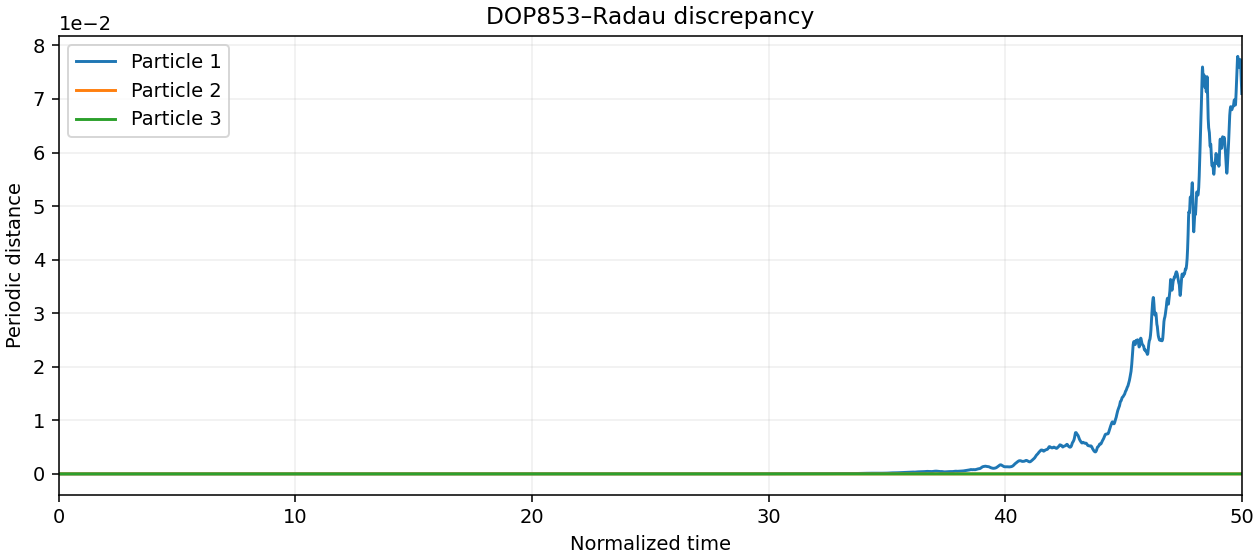

In [3]:
from visualization.radial_reference import plot_reference_discrepancy_until
import matplotlib.pyplot as plt

DISCREPANCY_END_TIME = 50.0  # Normalized time, matching the saved time axis.
fig, ax = plot_reference_discrepancy_until(reference, end_time=DISCREPANCY_END_TIME)
plt.show()

## View this execution later

Open [h5_three_radial_reference_visualization.ipynb](h5_three_radial_reference_visualization.ipynb) and set `VERSION` to the version printed above. The viewer loads the saved arrays and metadata without recomputing either solver. Keep `trajectory.npz`, `metadata.json` and `README.md` together in the artifact directory.
